# Sunrise Social Club: Exploratory Data Analysis

**Objective:**
Analyze cafe sales data to understand product performance, customer behavior, and operational patterns across items, flavors, customization options, and time of day.

## Section 1: Loading the Data & Overview

In [1380]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1381]:
#loading the data
df = pd.read_csv("../data/processed/sales_merged.csv")
df.head()

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location
0,2026-06-30,12:56:37,Cold Brew,Cold Brew,Whole Milk,False,1.0,8.0,16oz,True,Salted Maple,77.0,Sunny,Market,Kill Devil Hills
1,2026-06-30,12:54:50,Matcha Latte,Matcha Latte,Oat Milk,False,1.0,8.0,12oz,True,Blueberry,77.0,Sunny,Market,Kill Devil Hills
2,2026-06-30,12:37:26,Cold Brew,Cold Brew,Oat Milk,False,1.0,7.0,12oz,True,Blueberry,77.0,Sunny,Market,Kill Devil Hills
3,2026-06-30,12:37:26,Matcha Latte,Matcha Latte,Oat Milk,False,1.0,8.0,12oz,True,Blueberry,77.0,Sunny,Market,Kill Devil Hills
4,2026-06-30,12:35:29,Matcha Latte,Matcha Latte,Oat Milk,False,1.0,9.0,16oz,True,Blueberry,77.0,Sunny,Market,Kill Devil Hills


Each row represents a single line-item transaction (not a full customer order). Orders may contain multiple items across multiple rows.

In [1382]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1702 entries, 0 to 1701
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1702 non-null   object 
 1   Time               1702 non-null   object 
 2   Original_Item      1702 non-null   object 
 3   Item               1702 non-null   object 
 4   Base               1289 non-null   object 
 5   Signature_Drink    1702 non-null   bool   
 6   Qty                1702 non-null   float64
 7   Net_Sales          1702 non-null   float64
 8   Size               1419 non-null   object 
 9   Cold_Foam          1702 non-null   bool   
 10  Flavor             1383 non-null   object 
 11  Avg_Temp           1702 non-null   float64
 12  Weather_Condition  1702 non-null   object 
 13  Event_Type         1702 non-null   object 
 14  Location           1702 non-null   object 
dtypes: bool(2), float64(3), object(10)
memory usage: 176.3+ KB


,Qty,Net_Sales,Avg_Temp
count,1702.000000,1702.000000,1702.000000
mean,1.116921,7.626569,80.723267
std,0.369098,3.823757,3.279697
min,1.000000,2.000000,75.000000
25%,1.000000,6.000000,79.000000
50%,1.000000,8.000000,80.000000
75%,1.000000,8.000000,83.000000
max,4.000000,75.000000,86.000000


### Exploring Missing Values:

In [1383]:
# Percentage of missing values in each column
(df.isna().mean() * 100).sort_values(ascending=False)

Base                 24.265570
Flavor               18.742656
Size                 16.627497
Date                  0.000000
Time                  0.000000
Original_Item         0.000000
Item                  0.000000
Signature_Drink       0.000000
Qty                   0.000000
Net_Sales             0.000000
Cold_Foam             0.000000
Avg_Temp              0.000000
Weather_Condition     0.000000
Event_Type            0.000000
Location              0.000000
dtype: float64

### Data Quality Notes:

Several fields contain missing values due to limitations in the point-of-sale system, product characteristics, or operational inconsistencies.

- **Base** is missing for a subset of transactions. Some missing values occur because non-beverage merchandise items (e.g., stickers and mugs) do not require a liquid base, while others were mistakenly not input at the time of sale and could not be reliably determined from the available data. These values were retained as missing and later handled appropriately during beverage-specific analyses.
- **Size** is missing for some transactions. While size may be partially inferable from pricing, reconstructing it would require assumptions about add-ons and pricing rules, so missing values were retained.
- **Flavor** is missing for transactions where no flavor was added (e.g., plain Cold Brew, Matcha Latte, or Lemonade). Additionally, merchandise items do not have associated flavor selections. These missing values therefore represent valid non-selections rather than data entry errors.
- Core transaction fields (**Date, Time, Item, Quantity, and Net Sales**) are complete and serve as the primary basis for analysis.

In [1384]:
df['Base']= df['Base'].fillna('Unknown')
df['Size']= df['Size'].fillna('Unknown')
df['Flavor']= df['Flavor'].fillna('No Syrup')

## Section 2: Business Performance Overview

### 2.1 Sales Overview

In [1385]:
print(f'Total Net Sales: ${df["Net_Sales"].sum():,.2f}')
print(f'Total Quantity Sold: {df["Qty"].sum():,}')

Total Net Sales: $12,980.42
Total Quantity Sold: 1,901.0


In [1386]:
df["Net_Sales"].describe()

count    1702.000000
mean        7.626569
std         3.823757
min         2.000000
25%         6.000000
50%         8.000000
75%         8.000000
max        75.000000
Name: Net_Sales, dtype: float64

### 2.2 Customer Order Value

In [1387]:
order_level = (
    df.groupby(["Date", "Time"])["Net_Sales"]
      .sum()
)

# Summary statistics
print(order_level.describe())

print(f"Average Order Value: ${order_level.mean():.2f}")
print(f"Median Order Value: ${order_level.median():.2f}")

count    1140.000000
mean       11.386333
std         6.526090
min         2.000000
25%         8.000000
50%         9.000000
75%        15.000000
max        93.000000
Name: Net_Sales, dtype: float64
Average Order Value: $11.39
Median Order Value: $9.00


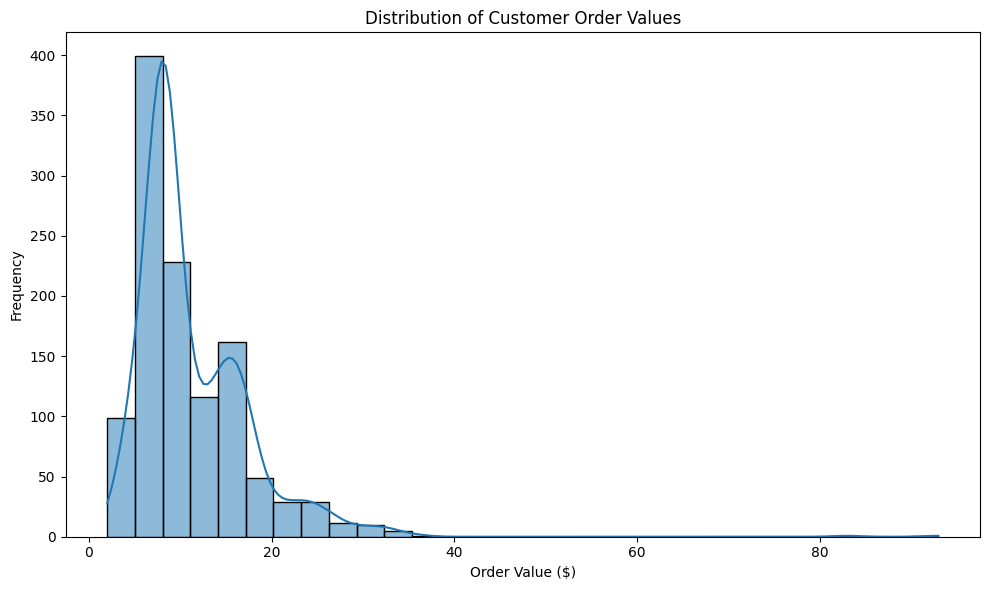

In [1388]:
plt.figure(figsize=(10, 6))
sns.histplot(order_level, bins=30, kde=True)
plt.title("Distribution of Customer Order Values")
plt.xlabel("Order Value ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Most customer orders fall between $8 and $14, with an average order value of $11.43. A small number of larger purchases create a right-skewed distribution.

## Section 3: Product Performance
This section explores which products drive demand and revenue.

### 3.1 Revenue by Item

In [1389]:
items_by_revenue = df.groupby('Item')['Net_Sales'].sum().sort_values(ascending=False)
items_by_revenue

Item
Matcha Latte    6678.42
Cold Brew       4375.00
Lemonade        1529.00
Sticker          248.00
Mug              150.00
Name: Net_Sales, dtype: float64

### 3.2 Quantity Sold by Item

In [1390]:
items_by_quantity = df.groupby('Item')['Qty'].sum().sort_values(ascending=False)
items_by_quantity

Item
Matcha Latte    817.0
Cold Brew       602.0
Lemonade        356.0
Sticker         124.0
Mug               2.0
Name: Qty, dtype: float64

### 3.3 Revenue vs. Quantity

In [1391]:
item_stats = df.groupby("Item").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False)

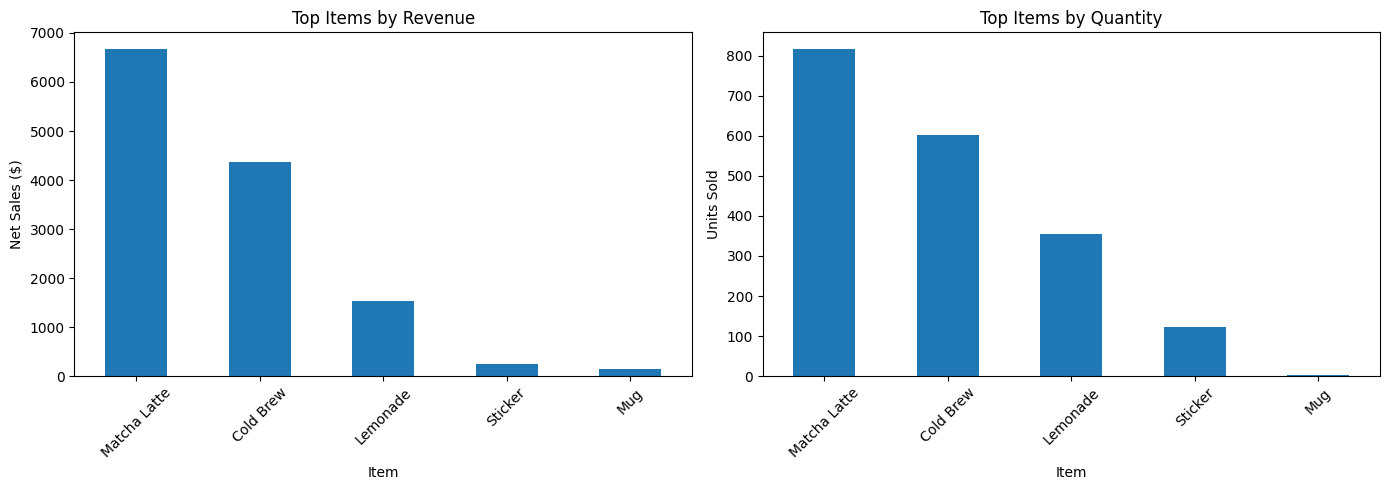

In [1392]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue
item_stats["Net_Sales"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Top Items by Revenue")
axes[0].set_ylabel("Net Sales ($)")
axes[0].tick_params(axis='x', rotation=45)

# Quantity
item_stats["Qty"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Top Items by Quantity")
axes[1].set_ylabel("Units Sold")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

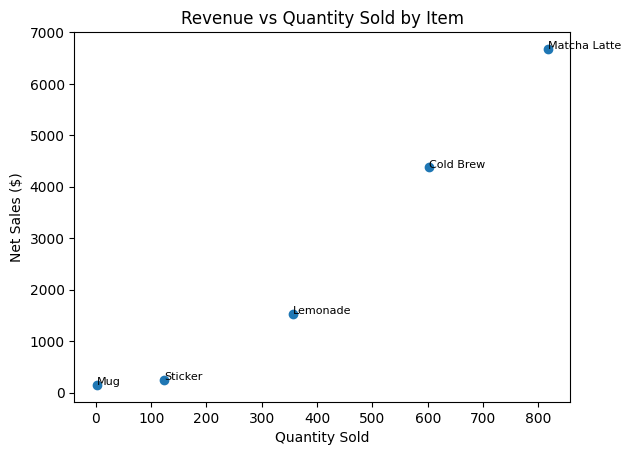

In [1393]:
plt.scatter(item_stats["Qty"], item_stats["Net_Sales"])
plt.xlabel("Quantity Sold")
plt.ylabel("Net Sales ($)")
plt.title("Revenue vs Quantity Sold by Item")

for i in item_stats.index:
    plt.text(item_stats.loc[i, "Qty"], item_stats.loc[i, "Net_Sales"], i, fontsize=8)

plt.show()

- Matcha Latte dominates both revenue and quantity, indicating it is the core driver of both demand and sales.
- Cold Brew shows high volume but lower revenue efficiency compared to Matcha Latte, suggesting lower price per unit.
- Lemonade performs relatively well in quantity but contributes less revenue, reinforcing its role as a high-volume, lower-margin product.
- Merchandise items (Sticker, Mug) generate revenue despite low volume, highlighting their role as high-margin add-ons rather than core demand drivers.

## Section 4: Customer Preferences

In [1394]:
# Filter dataset to only include drink items
drink_items = ["Matcha Latte", "Cold Brew", "Lemonade"]

drink_df = df[df["Item"].isin(drink_items)]

### 4.1 Flavor Popularity

In [1395]:
flavor_stats = drink_df.groupby("Flavor").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False)
flavor_stats

,Net_Sales,Qty
Flavor,,
Strawberry,3852.58,535.0
Blueberry,2099.00,275.0
Salted Maple,1754.66,226.0
No Syrup,1375.18,261.0
Banana,1172.00,147.0
Vanilla,982.00,132.0
Cinn Roll,837.00,108.0
"Strawberry, Blueberry",286.00,63.0
Cake Batter,224.00,28.0


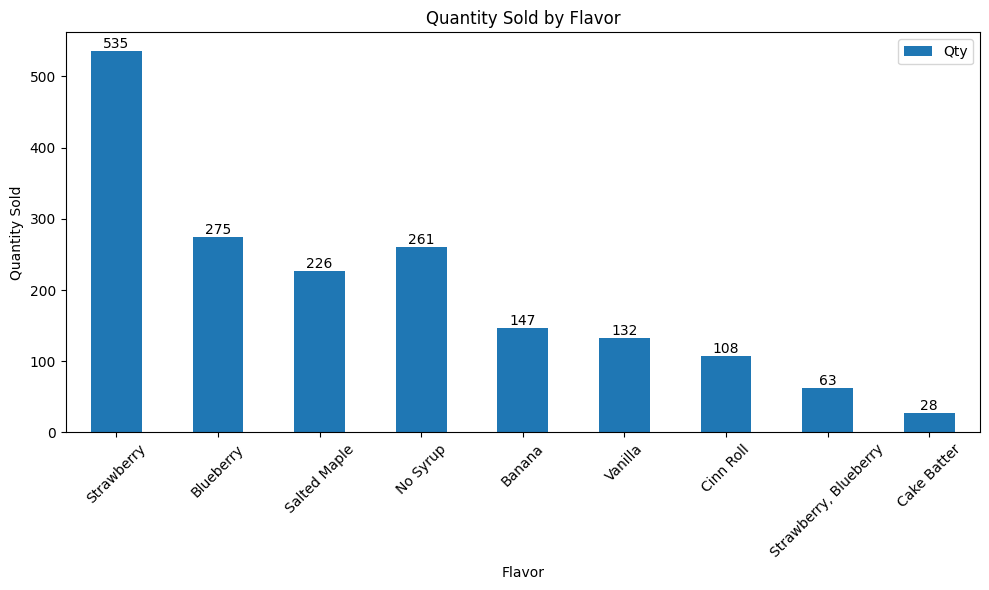

In [1396]:
flavor_stats.plot(kind="bar", y="Qty", figsize=(10, 6))
plt.title("Quantity Sold by Flavor")
plt.ylabel("Quantity Sold")
plt.xlabel("Flavor")
plt.xticks(rotation=45)
plt.tight_layout()
for container in plt.gca().containers:
    labels = [f"{v:,.0f}" if v > 0 else "" for v in container.datavalues]
    plt.gca().bar_label(container, labels=labels, label_type="edge")
plt.show()

Strawberry was the most frequently selected flavor, suggesting strong customer preference for fruit-based drinks.

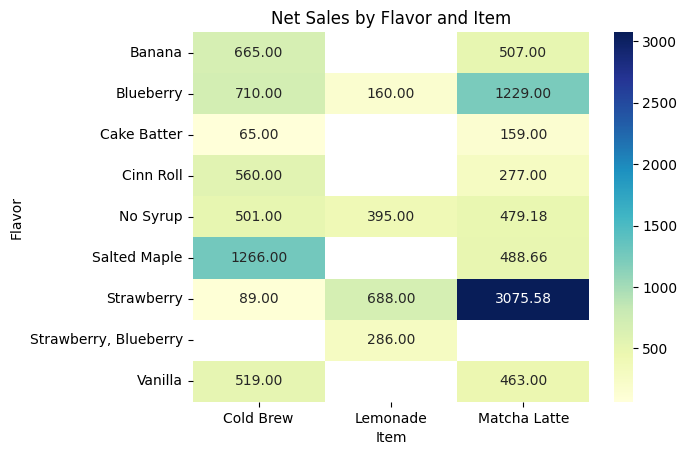

In [1397]:
pivot = drink_df.pivot_table(
    index="Flavor",
    columns="Item",
    values="Net_Sales",
    aggfunc="sum"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Net Sales by Flavor and Item")
plt.xlabel("Item")
plt.ylabel("Flavor")
plt.show()

The heatmap reveals that strawberry was the most popular flavor for both matcha lattes and lemonades, while salted maple was the most popular flavor for cold brews.

### 4.2 Base Preferences

This section analyzes base preferences for Matcha Latte and Cold Brew, where customers can select between whole milk, oat milk, and lemonade (as a customization add-in for Matcha). Lemonade is included here only as a base-level modification option rather than a standalone beverage, allowing for comparison of how customers customize drinks across categories.

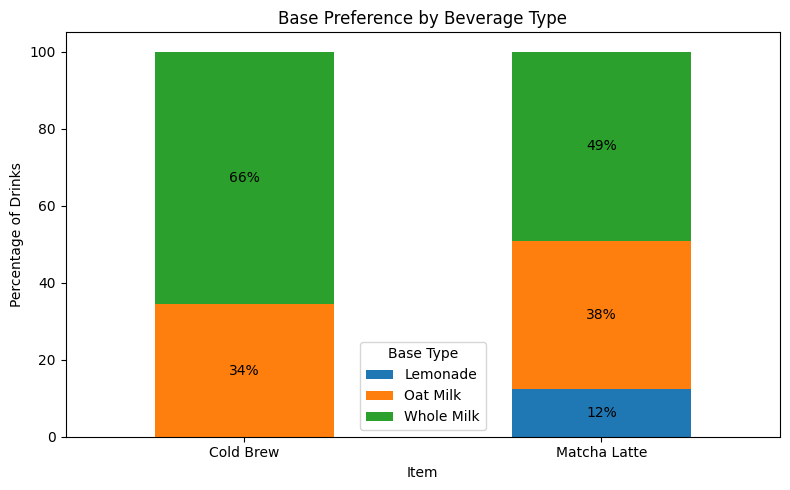

In [1398]:
# Base Preference by Beverage Type
base_item_pct = (
    drink_df[drink_df["Item"].isin(["Matcha Latte", "Cold Brew"])]
      .query('Base in ["Whole Milk", "Oat Milk", "Lemonade"]')
      .groupby(["Item", "Base"])["Qty"]
      .sum()
      .unstack(fill_value=0)
)

# Convert to percentages
base_item_pct = base_item_pct.div(
    base_item_pct.sum(axis=1), axis=0
) * 100

ax = base_item_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Base Preference by Beverage Type")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Item")
plt.xticks(rotation=0)
plt.legend(title="Base Type")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

Whole milk appears to be the most popular base choice for both Cold Brew and Matcha Latte, suggesting that most customers prefer traditional dairy options.

### 4.3 Cold Foam Preferences

In [1399]:
drink_df.groupby("Cold_Foam").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False) 

,Net_Sales,Qty
Cold_Foam,,
True,7771.50,956.0
False,4810.92,819.0


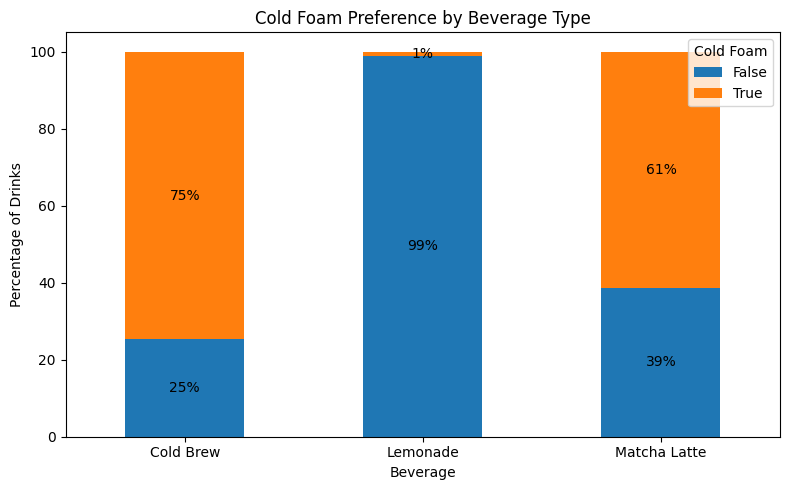

In [1400]:
foam_by_item = (
    drink_df.groupby(["Item", "Cold_Foam"])["Qty"]
    .sum()
    .unstack(fill_value=0)
)

foam_by_item_pct = foam_by_item.div(foam_by_item.sum(axis=1), axis=0) * 100

ax = foam_by_item_pct.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Cold Foam Preference by Beverage Type")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Beverage")
plt.xticks(rotation=0)
plt.legend(title="Cold Foam")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

Cold brew was more likely to have cold foam added than a matcha latte. Lemonade, as expected, was not often paired with cold foam.

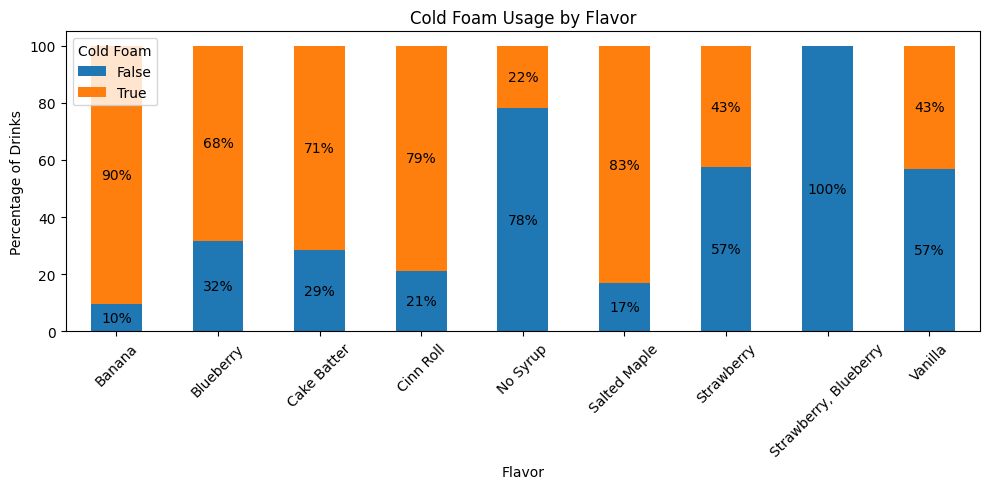

In [1401]:
foam_by_flavor = (
    drink_df.groupby(["Flavor", "Cold_Foam"])["Qty"]
    .sum()
    .unstack(fill_value=0)
)

foam_by_flavor_pct = foam_by_flavor.div(foam_by_flavor.sum(axis=1), axis=0) * 100

ax = foam_by_flavor_pct.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Cold Foam Usage by Flavor")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Flavor")
plt.xticks(rotation=45)
plt.legend(title="Cold Foam")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

Certain flavors were disproportionately associated with cold foam additions, which reflects featured menu combinations. For example, the banana, cinnamon roll, and salted maple syrups had featured specials on the menu that included cold foam.

## Section 5: Event and Operational Analysis

### 5.1 Revenue by Event Type

In [1402]:
df.groupby("Event_Type")["Net_Sales"].sum()

Event_Type
Market    11609.42
Popup      1371.00
Name: Net_Sales, dtype: float64

In [1403]:
# Average daily sales by event type
daily_sales = (
    df.groupby(["Date", "Event_Type"])["Net_Sales"]
      .sum()
      .reset_index()
)

avg_sales = (
    daily_sales.groupby("Event_Type")["Net_Sales"]
    .mean()
    .sort_values(ascending=False)
)

avg_sales

Event_Type
Market    1160.942
Popup      457.000
Name: Net_Sales, dtype: float64

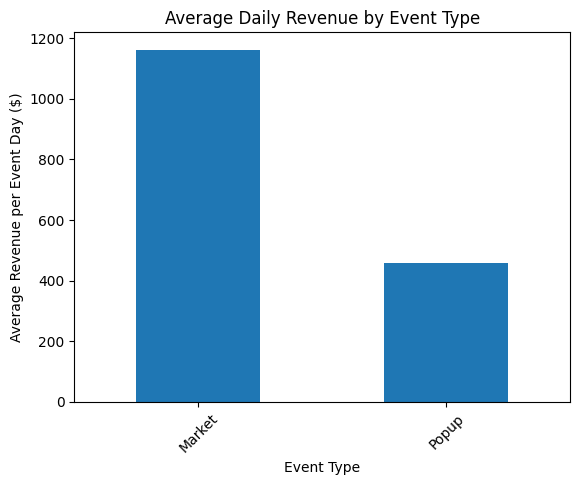

In [1404]:
avg_sales.plot(kind="bar")
plt.title("Average Daily Revenue by Event Type")
plt.ylabel("Average Revenue per Event Day ($)")
plt.xlabel("Event Type")
plt.xticks(rotation=45)
plt.show()

Markets generated the highest average daily revenue, reinforcing their importance as the primary sales channel.

### 5.2 Revenue by Market Location

Note: Market locations differ in external setup costs (Manteo and First Flight: $25 entry fee; Soundside: $160 entry fee), which are not included in the dataset. Therefore, revenue comparisons reflect observed sales performance only and do not account for differences in operating costs or market scale.


In [1405]:
# Filter dataset to only include market locations
market_locations = ["Manteo", "Kill Devil Hills", "Nags Head"]

market_df = df[df["Location"].isin(market_locations)]

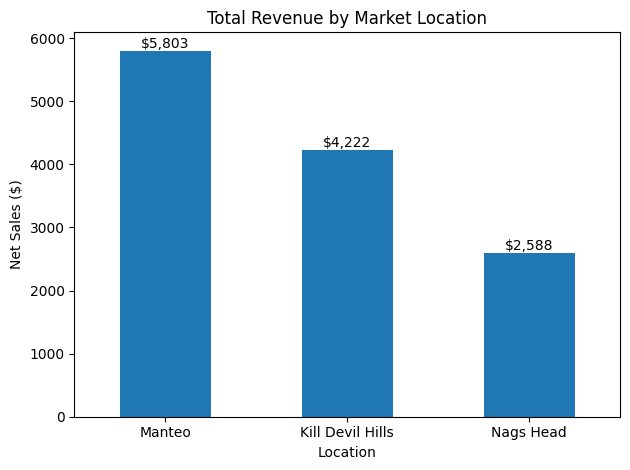

In [1406]:
# Total revenue by market location
location_revenue = (
    market_df.groupby("Location")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

location_revenue.plot(kind="bar")
plt.title("Total Revenue by Market Location")
plt.xlabel("Location")
plt.ylabel("Net Sales ($)")
plt.xticks(rotation=0)
for container in plt.gca().containers:
    labels = [f"${v:,.0f}" if v > 0 else "" for v in container.datavalues]
    plt.gca().bar_label(container, labels=labels, label_type="edge")
plt.tight_layout()
plt.show()

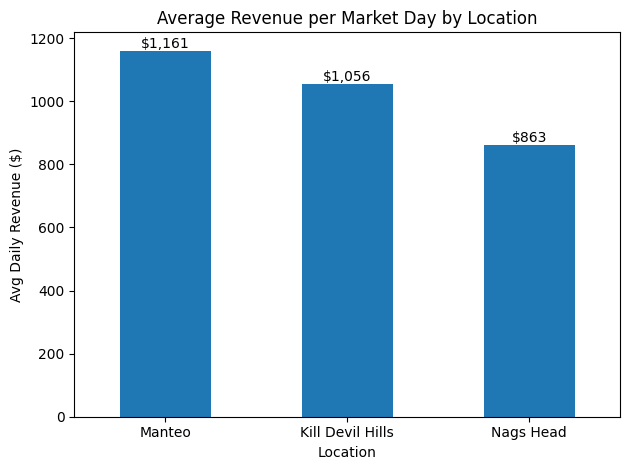

In [1407]:
# Average daily revenue by market location
daily_market = (
    market_df.groupby(["Date", "Location"])["Net_Sales"]
    .sum()
    .reset_index()
)

avg_market = (
    daily_market.groupby("Location")["Net_Sales"]
    .mean()
    .sort_values(ascending=False)
)

avg_market.plot(kind="bar")
plt.title("Average Revenue per Market Day by Location")
plt.ylabel("Avg Daily Revenue ($)")
plt.xlabel("Location")
plt.xticks(rotation=0)

for container in plt.gca().containers:
    labels = [f"${v:,.0f}" if v > 0 else "" for v in container.datavalues]
    plt.gca().bar_label(container, labels=labels, label_type="edge")
plt.tight_layout()
plt.show()


The Manteo market on Saturdays generated the highest average daily revenue.

### 5.3 Time-Based Patterns

In [1408]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/var/folders/w2/4nk24xz14yg09dbpyrxdn4c80000gn/T/ipykernel_73939/816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


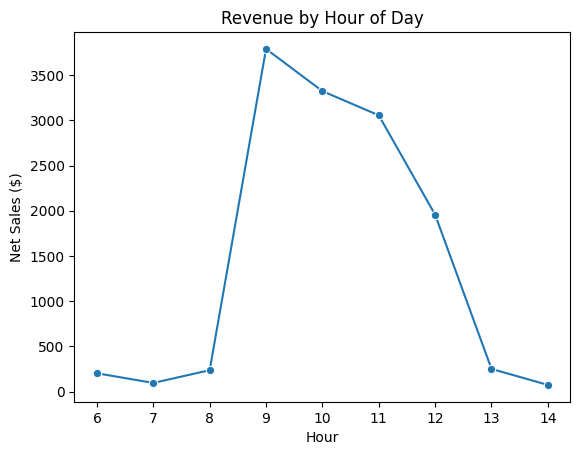

In [1409]:
# Revenue by hour
hourly_sales = df.groupby("Hour")["Net_Sales"].sum().reset_index()

sns.lineplot(
    data=hourly_sales,
    x="Hour",
    y="Net_Sales",
    marker="o"
)

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Net Sales ($)")
plt.xticks(hourly_sales["Hour"])
plt.show()

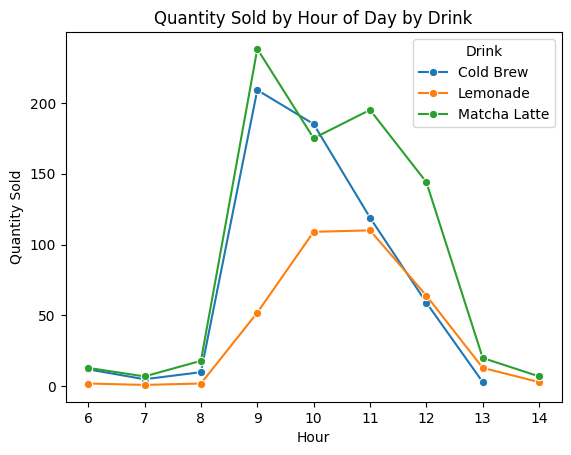

In [1410]:
# Revenue by hour for each drink
hourly_sales = (
    df[df["Item"].isin(["Matcha Latte", "Cold Brew", "Lemonade"])]
    .groupby(["Hour", "Item"])["Qty"]
    .sum()
    .reset_index()
)

sns.lineplot(
    data=hourly_sales,
    x="Hour",
    y="Qty",
    hue="Item",
    marker="o"
)

plt.title("Quantity Sold by Hour of Day by Drink")
plt.xlabel("Hour")
plt.ylabel("Quantity Sold")
plt.xticks(sorted(hourly_sales["Hour"].unique()))
plt.legend(title="Drink")
plt.show()

The peak sales hours are from 9am-1pm, which the time frame in which all of the markets occur. In that, the first hour of the markets, 9-10am, generates the most revenue.

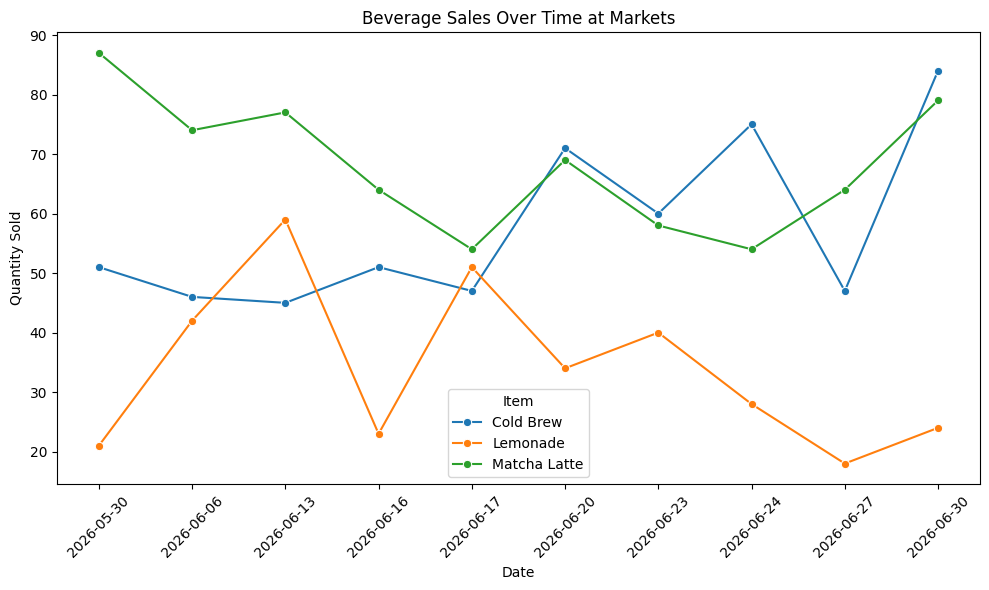

In [1411]:
# Beverage demand trends over time
market_drinks = drink_df[
    drink_df["Event_Type"] == "Market"
]

daily_item_sales = (
    market_drinks.groupby(["Date", "Item"])["Qty"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=daily_item_sales,
    x="Date",
    y="Qty",
    hue="Item",
    marker="o"
)

plt.title("Beverage Sales Over Time at Markets")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Cold Brew sales appear to increase over the observation period. One possible explanation is that customers initially purchased Matcha Lattes due to the novelty of a new product offering, then gradually returned to more familiar beverage preferences. However, additional data would be needed to distinguish between novelty effects, seasonal influences, and longer-term shifts in customer demand.

## Section 6: Key Insights and Recommendations

### Key Insights
- Matcha Latte is the dominant revenue and volume driver, indicating it is the core product anchor.
- Customer preferences are strongly influenced by flavor, with strawberry consistently performing best across beverages.
- Customization behavior (milk choice and cold foam) varies significantly by beverage type, suggesting product-specific customer behavior patterns.
- Market events generate significantly higher revenue than other event types and represent the primary sales channel.
- Sales are heavily concentrated in morning hours (9 AM–1 PM), aligning with market operating schedules.

### Recommendations
- Prioritize inventory for Matcha Latte and high-performing flavor syrups (especially strawberry).
- Continue focusing on market-based sales as the primary growth channel.
- Optimize staffing and preparation around morning peak demand periods.
- Tailor customization offerings (milk and cold foam options) by beverage type to improve efficiency and upselling.